# Exercise 16.1 solution


## Exercise 16.1a solution


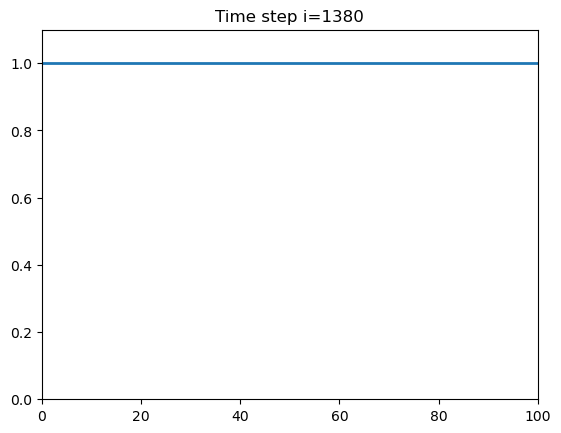

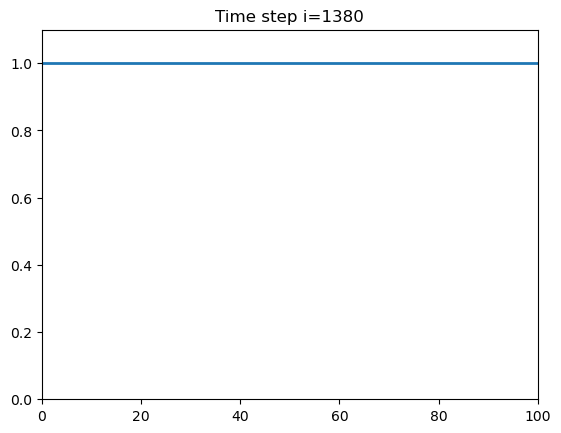

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import time

# Parameters
k = 2.0
A = 1.0
alpha = 0.1
L = 100

dx = 1
dt = 0.1
N = int(L / dx)

# Initialize arrays
v = np.zeros(N + 1)
left = int(N / 10)
v[:left] = 0.3  # Apply the initial stimulus


def f(V):
    return A * V * (1 - V) * (V - alpha)


# Safely copy to preserve the previous time step
v_prev = np.copy(v)

# Simulation loop
for i in range(1400):
    # 1. Update internal nodes
    for j in range(1, N):
        I_ion = f(v_prev[j])
        diff = (k / dx**2) * (v_prev[j + 1] - 2 * v_prev[j] + v_prev[j - 1])
        v[j] = v_prev[j] + dt * diff + dt * I_ion

    # 2. Update boundaries
    v[0] = (
        v_prev[0] + dt * (k / dx**2) * 2 * (v_prev[1] - v_prev[0]) + dt * f(v_prev[0])
    )
    v[N] = (
        v_prev[N]
        + dt * (k / dx**2) * 2 * (v_prev[N - 1] - v_prev[N])
        + dt * f(v_prev[N])
    )

    # 3. Save the new state for the next step!
    v_prev = np.copy(v)

    if i % 20 == 0:
        plt.clf()
        plt.axis([0, L, 0, 1.1])
        plt.plot(v, color="C0", linewidth=2)
        plt.title(f"Time step i={i}")
        display.clear_output(wait=True)
        display.display(plt.gcf())
        time.sleep(0.01)

## Exercise 16.1b solution


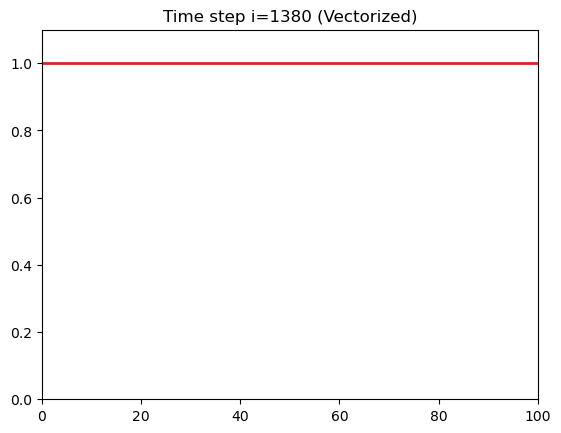

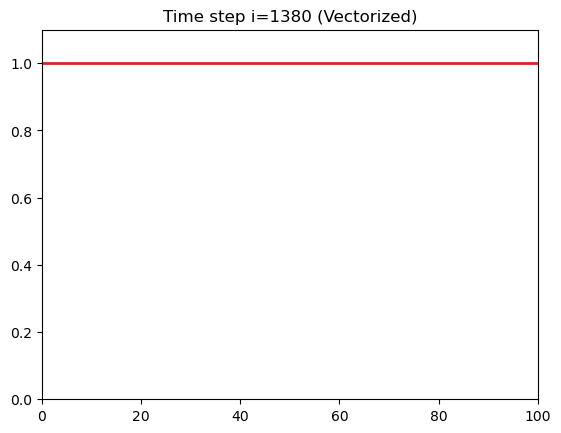

In [2]:
# Reset initial conditions
v = np.zeros(N + 1)
v[:left] = 0.3

# Introduce the appropriate arrays for slicing
I = np.arange(1, N)
Ip = I + 1
Im = I - 1

for i in range(1400):
    # Calculate reaction for ALL nodes
    I_ion = f(v)

    v_prev = np.copy(v)

    # Vectorized diffusion update
    v[I] = v_prev[I] + dt * (k / dx**2) * (v_prev[Ip] - 2 * v_prev[I] + v_prev[Im])

    # Update boundaries
    v[0] = v_prev[0] + dt * (k / dx**2) * 2 * (v_prev[1] - v_prev[0])
    v[N] = v_prev[N] + dt * (k / dx**2) * 2 * (v_prev[N - 1] - v_prev[N])

    # Add the reaction term simultaneously
    v = v + dt * I_ion

    if i % 20 == 0:
        plt.clf()
        plt.axis([0, L, 0, 1.1])
        plt.plot(v, color="C3", linewidth=2)
        plt.title(f"Time step i={i} (Vectorized)")
        display.clear_output(wait=True)
        display.display(plt.gcf())
        time.sleep(0.01)